In [2]:
import math
import numpy as np
from SDP_utils.combinatorics import occupation_index, nu_set_iterator, multinomial, nu_iterator, dim_sym_kd
from SDP_utils.isotopic_proj import isotypic_projector
from tqdm.notebook import tqdm
import numpy as np
import picos
from SDP_utils.E_t import E_t_lowerk2
from toqito.state_props import is_separable

SDP_TOL = 10 ** (-7)

In [3]:
from SDP_utils.sdp import SDP

In [4]:
import os
import json
import numpy as np
from tqdm.notebook import tqdm
from SDP_utils.sdp import SDP, SDP_max
from SDP_utils.E_t import E_t_lowerk2, E_t_upperk2r2
from toqito.state_props import is_separable

SDP_TOL = 10 ** (-7)
RESULTS_DIR = "sdp_results"

# Parameter values are used as dictionary keys to decide whether a point has
# already been computed, so they are rounded first: np.arange happily produces
# 0.15000000000000002 instead of 0.15, and two sweeps built with different
# steps must still agree on what "the point p = 0.15" means.
P_DECIMALS = 10

# Keys of a single record (one line) in a .jsonl cache file.
RECORD_FIELDS = ("p", "obj", "separable", "Etl", "obj_max", "Etu")
RECORD_FIELDS_2D = ("x", "y", "obj", "separable", "Etl")


def antiSymProjector(k):
    return [1] * k


def _safe_label(label):
    return "".join(c if c.isalnum() or c in "-_" else "_" for c in label)


def _cache_path(label, m, k):
    """Cache file for a 1-parameter sweep: depends on the *parameters only*,
    not on the range that happens to be requested."""
    os.makedirs(RESULTS_DIR, exist_ok=True)
    return os.path.join(RESULTS_DIR, f"{_safe_label(label)}_m{m}_k{k}.jsonl")


def _pkey(p):
    """Canonical key for a parameter value."""
    return round(float(p), P_DECIMALS)


def _grid(param_range):
    """Parameter grid for (start, end, step), end inclusive, canonicalized."""
    start, end, step = param_range
    return [_pkey(p) for p in np.arange(start, end + step / 2.0, step)]


def _dump_num(x):
    """NaN is not valid JSON, so it is stored as null."""
    x = float(x)
    return None if np.isnan(x) else x


def _load_num(x):
    return float("nan") if x is None else float(x)


def _load_records(filename, keyfunc=None):
    """Read a .jsonl cache file into {key: record}. Later lines win, so an
    appended re-computation of a point transparently supersedes the old one."""
    keyfunc = keyfunc or (lambda rec: _pkey(rec["p"]))
    records = {}
    if not os.path.exists(filename):
        return records
    with open(filename, "r") as f:
        for lineno, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                # e.g. a half-written line from a run killed mid-write
                print(f"[warn] {filename}:{lineno} is not valid JSON, skipping it")
                continue
            records[keyfunc(rec)] = rec
    return records


def _append_record(filename, rec):
    """Append one point, flushed to disk immediately (crash safety)."""
    with open(filename, "a") as f:
        f.write(json.dumps(rec) + "\n")
        f.flush()
        os.fsync(f.fileno())


def _rewrite_sorted(filename, records):
    """Rewrite the file with one sorted, de-duplicated line per point."""
    tmp = filename + ".tmp"
    with open(tmp, "w") as f:
        for key in sorted(records):
            f.write(json.dumps(records[key]) + "\n")
    os.replace(tmp, filename)


def _package(records, keys, m, label, param_range, k):
    """Turn {p_key: record} into the array-of-values dict the plotting code and
    the rest of the notebook expect. `keys` fixes the order and the selection."""
    keys = [key for key in keys if key in records]
    col = lambda name: np.array([_load_num(records[key].get(name)) for key in keys], dtype=float)
    return {
        "p_vals": np.array(keys, dtype=float),
        "obj_vals": col("obj"),
        "separable": np.array([int(records[key]["separable"]) for key in keys], dtype=int),
        "Etl_vals": col("Etl"),
        "obj_max_vals": col("obj_max"),
        "Etu_vals": col("Etu"),
        "m": m,
        "label": label,
        "range": tuple(param_range) if param_range is not None else None,
        "k": k,
    }


def load_SDP_bounds(label, m, k=2, param_range=None):
    """Load an existing cache file without computing anything.

    param_range : (start, end, step) or None
        If given, only the points of that grid are returned (in grid order);
        otherwise every point in the file is returned, sorted by p.
    """
    records = _load_records(_cache_path(label, m, k))
    keys = _grid(param_range) if param_range is not None else sorted(records)
    return _package(records, keys, m, label, param_range, k)


def get_SDP_bounds(m, generator, label, param_range, k=2, projector=None, force_recompute=False, verbose=True):
    """
    Sweep a 1-parameter family of states through the SDP, caching results to a
    JSONL file keyed by `label`, `m` and `k` only -- the range is *not* part of
    the filename. Each line of the file is one parameter point:

        {"p": ..., "obj": ..., "separable": ..., "Etl": ..., "obj_max": ..., "Etu": ...}

    Before solving, every point of the requested grid is looked up in that file
    and skipped if it is already there, so re-running with a different (or
    finer, or wider) range only computes the genuinely new points. Each point is
    appended as soon as it is computed, so an interrupted run loses at most the
    point in flight.

    In addition to the lower bound on E_t obtained from `SDP` + `E_t_lowerk2`,
    when `k == 2` this also runs `SDP_max` (same signature/return as `SDP`, but
    maximizing instead of minimizing the objective) and feeds its result through
    `E_t_upperk2r2` (hardcoded to k=2, r=2) to get an upper bound on E_t. This is
    only attempted for k == 2; for other k the upper-bound entries are NaN
    (stored as null in the file).

    Parameters
    ----------
    m : int
        Local dimension; states live in C^m x C^m.
    generator : callable
        Takes a single float `p` and returns the corresponding density matrix.
    label : str
        Human readable name used to build the cache filename, e.g. "C3C3_horodecki".
    param_range : tuple
        (start, end, step) fed to np.arange to build the parameter grid (end
        inclusive).
    k : int, default 2
        Symmetry degree, used for the default antisymmetric projector [1]*k and
        passed to E_t_lowerk2. Also gates the SDP_max / E_t_upperk2r2 upper bound.
    projector : list, optional
        Explicit projector spec forwarded to SDP() / SDP_max().
    force_recompute : bool, default False
        Recompute the points of the requested range even if cached (points
        outside the range are left untouched).
    verbose : bool, default True
        Print progress / cache hit messages and show a progress bar.

    Returns
    -------
    dict with keys p_vals, obj_vals, separable, Etl_vals, obj_max_vals, Etu_vals
    (numpy arrays restricted to `param_range`) plus the m, label, range, k metadata.
    """
    filename = _cache_path(label, m, k)
    grid = _grid(param_range)
    records = _load_records(filename)

    if force_recompute:
        dropped = [key for key in grid if key in records]
        if dropped:
            for key in dropped:
                records.pop(key)
            _rewrite_sorted(filename, records)
            if verbose:
                print(f"[get_SDP_bounds] force_recompute: dropped {len(dropped)} " f"cached point(s) from {filename}")

    todo = [p for p in grid if p not in records]

    if verbose:
        n_cached = len(grid) - len(todo)
        if n_cached:
            print(f"[get_SDP_bounds] {n_cached}/{len(grid)} point(s) already in " f"{filename}, computing the remaining {len(todo)}")
        else:
            print(f"[get_SDP_bounds] computing {len(todo)} point(s) into {filename}")

    proj = projector if projector is not None else antiSymProjector(k)
    compute_upper = k == 2

    iterator = tqdm(todo, desc=label) if (verbose and todo) else todo

    for p in iterator:
        state = generator(p)
        obj, omega_sym = SDP(proj, state, m, m)

        sep, reason = is_separable(state)
        if reason.startswith("inconclusive"):
            sep = 1
        else:
            sep = 2 if sep else 0

        if obj > SDP_TOL:
            Etl = float(E_t_lowerk2(k, 1, obj))
        else:
            Etl = 0.0

        if compute_upper:
            obj_max, _ = SDP_max(proj, state, m, m)
            obj_max = float(obj_max)
            Etu = float(E_t_upperk2r2(obj_max))
        else:
            obj_max = float("nan")
            Etu = float("nan")

        rec = {
            "p": p,
            "obj": _dump_num(obj),
            "separable": int(sep),
            "Etl": _dump_num(Etl),
            "obj_max": _dump_num(obj_max),
            "Etu": _dump_num(Etu),
        }
        records[p] = rec
        _append_record(filename, rec)

    if todo:
        # keep the file tidy: one sorted, de-duplicated line per point
        _rewrite_sorted(filename, records)
        if verbose:
            print(f"[get_SDP_bounds] {filename} now holds {len(records)} point(s)")

    return _package(records, grid, m, label, param_range, k)


def convex_combination_generator(state1, state2):
    """
    Build a single-parameter generator g(p) = p * state1 + (1 - p) * state2,
    suitable for get_SDP_bounds. Use this to turn e.g. cross_hatch() /
    max_mixed(m**2) into the `generator` argument.

    NB: check this matches the convention used by your own
    CmCn_entangled.convex_combination.convex_combination iterator
    (some implementations use p*state2 + (1-p)*state1 instead) and swap the
    two terms below if needed.
    """

    def gen(p):
        return p * state1 + (1 - p) * state2

    return gen


import matplotlib.pyplot as plt


def _as_results(results, param_range):
    """Accept either a dict returned by get_SDP_bounds / load_SDP_bounds, or the
    path of a .jsonl cache file, and restrict it to `param_range` if given."""
    if isinstance(results, str):
        records = _load_records(results)
        keys = _grid(param_range) if param_range is not None else sorted(records)
        return _package(records, keys, None, os.path.basename(results), param_range, None)

    if param_range is None:
        return results

    wanted = set(_grid(param_range))
    p_vals = np.asarray(results["p_vals"], dtype=float)
    mask = np.array([_pkey(p) in wanted for p in p_vals], dtype=bool)
    out = dict(results)
    for key in ("p_vals", "obj_vals", "separable", "Etl_vals", "obj_max_vals", "Etu_vals"):
        out[key] = np.asarray(results[key])[mask]
    out["range"] = tuple(param_range)
    return out


def plot_Etl_bounds(results, title, param_range=None, xlabel="p"):
    """
    Plot the Etl_vals (lower bound) of a sweep on a log scale, color-coding
    separable / inconclusive / entangled points.

    Parameters
    ----------
    results : dict or str
        Either the dict returned by get_SDP_bounds() / load_SDP_bounds(), or the
        path of a .jsonl cache file (e.g. "sdp_results/random_PPT_m3_k2.jsonl").
    param_range : (start, end, step), optional
        Since the cache files no longer carry a range, this selects which points
        are plotted. Omit it to plot everything the file / dict contains.

    If Etu_vals holds real (non-NaN) values -- populated by get_SDP_bounds only
    when k == 2 -- the E_t_upperk2r2 upper bound curve is overlaid as well.
    """
    results = _as_results(results, param_range)

    p_vals = np.asarray(results["p_vals"], dtype=float)
    Etl_vals = np.asarray(results["Etl_vals"], dtype=float)
    separable = np.asarray(results["separable"], dtype=int)

    if len(p_vals) == 0:
        print(f"[plot_Etl_bounds] nothing to plot for '{title}' " f"(range {results.get('range')})")
        return

    eps = 1e-6
    plot_vals = np.where(Etl_vals <= 0, eps, Etl_vals)

    plt.figure(figsize=(7, 5))
    plt.plot(p_vals, plot_vals, color="gray", linestyle="-", alpha=0.6, zorder=1, label="$E_t^{lower}$")
    mask = separable == 0
    plt.scatter(p_vals[mask], plot_vals[mask], color="crimson", marker="o", s=50, label="entangled", zorder=2)
    mask = separable == 1
    plt.scatter(p_vals[mask], plot_vals[mask], color="orange", marker="h", s=60, label="inconclusive", zorder=2)
    mask = separable == 2
    plt.scatter(p_vals[mask], plot_vals[mask], color="royalblue", marker="x", s=60, label="separable", zorder=2)

    Etu_vals = np.asarray(results.get("Etu_vals", []), dtype=float)
    if len(Etu_vals) == len(p_vals) and not np.all(np.isnan(Etu_vals)):
        valid = ~np.isnan(Etu_vals)
        Etu_plot = np.where(Etu_vals[valid] <= 0, eps, Etu_vals[valid])
        plt.plot(
            p_vals[valid],
            Etu_plot,
            color="darkorange",
            linestyle="--",
            marker="^",
            markersize=6,
            alpha=0.85,
            zorder=1,
            label="$E_t^{upper}$ ($k{=}2, r{=}2$)",
        )

    plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("$E_{t}$ bound (log scale)")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=8)
    plt.show()


def _cache_path_2d(label, m, k):
    """Cache file for a 2-parameter sweep: like the 1-parameter one, the range
    is not part of the name."""
    os.makedirs(RESULTS_DIR, exist_ok=True)
    return os.path.join(RESULTS_DIR, f"{_safe_label(label)}_m{m}_k{k}_2d.jsonl")


def _xykey(x, y):
    return (_pkey(x), _pkey(y))


def _xykey_of(rec):
    return _xykey(rec["x"], rec["y"])


def _package_2d(records, keys, m, label, k):
    keys = [key for key in keys if key in records]
    col = lambda name: np.array([_load_num(records[key].get(name)) for key in keys], dtype=float)
    return {
        "x_vals": np.array([key[0] for key in keys], dtype=float),
        "y_vals": np.array([key[1] for key in keys], dtype=float),
        "obj_vals": col("obj"),
        "separable": np.array([int(records[key]["separable"]) for key in keys], dtype=int),
        "Etl_vals": col("Etl"),
        "m": m,
        "label": label or _pretty_label(default_label),
        "k": k,
    }


def load_SDP_bounds_2d(label, m, k=2):
    """Load a 2-parameter cache file without computing anything."""
    filename = _cache_path_2d(label, m, k)
    records = _load_records(filename, _xykey_of)
    return _package_2d(records, sorted(records), m, label, k)


def get_SDP_bounds_2d(m, generator, label, param_range=None, k=2, projector=None, force_recompute=False, verbose=True):
    """
    2-parameter analogue of get_SDP_bounds, for state families like the Yu-Oh
    states that are indexed by a pair (x, y) instead of a single p.

    Unlike get_SDP_bounds (which takes a callable generator(p) -> state and builds
    the grid itself), here `generator` is an *iterable* -- typically a generator
    function call such as yu_oh_gen(3, 0.0, 1.0, 0.1) -- yielding
    ((x, y), state) pairs. The (x, y) values swept are whatever it produces.

    Caching works exactly like the 1-parameter version: one JSONL file per family,
    `sdp_results/<label>_m<m>_k<k>_2d.jsonl`, with one line per point,

        {"x": 0.1, "y": 0.3, "obj": ..., "separable": ..., "Etl": ...}

    and a point yielded by the generator is skipped if it is already in the file.
    Sweeping the same family again with a finer step therefore only solves the
    genuinely new (x, y) pairs.

    Parameters
    ----------
    m : int
        Local dimension; states live in C^m x C^m.
    generator : iterable of ((float, float), np.ndarray)
        Yields (x, y) pairs together with the corresponding density matrix.
    label : str
        Name used to build the cache filename. Two different state families must
        NOT share a label, or they end up in the same file.
    param_range : tuple, optional
        (start, end, step) used only to size the progress bar; the grid itself
        comes from `generator`.
    k : int, default 2
        Symmetry degree, forwarded to E_t_lowerk2 and used for the default
        antisymmetric projector. Part of the cache filename.
    force_recompute : bool, default False
        Recompute the points yielded by `generator` even if they are cached.
    verbose : bool, default True
        Print progress / cache-hit messages and show a progress bar.

    Returns
    -------
    dict with keys x_vals, y_vals, obj_vals, separable, Etl_vals, m, label, k,
    restricted to the points `generator` yielded during this call.
    """
    filename = _cache_path_2d(label, m, k)
    records = _load_records(filename, _xykey_of)
    proj = projector if projector is not None else antiSymProjector(k)

    total = None
    if param_range is not None:
        # best effort: at most n_side**2 grid points can pass the validity
        # checks inside the generator, usually far fewer will
        total = len(_grid(param_range)) ** 2
    iterator = tqdm(generator, desc=label, total=total) if verbose else generator

    visited, n_new, n_cached = [], 0, 0

    for (x, y), state in iterator:
        key = _xykey(x, y)
        visited.append(key)

        if key in records and not force_recompute:
            n_cached += 1
            continue

        obj, omega_sym = SDP(proj, state, m, m)

        sep, reason = is_separable(state)
        if reason.startswith("inconclusive"):
            sep = 1
        else:
            sep = 2 if sep else 0

        if obj > SDP_TOL:
            Etl = float(E_t_lowerk2(k, 1, obj))
        else:
            Etl = 0.0

        rec = {
            "x": key[0],
            "y": key[1],
            "obj": _dump_num(obj),
            "separable": int(sep),
            "Etl": _dump_num(Etl),
        }
        records[key] = rec
        # persist after every point, same crash-safety rationale as get_SDP_bounds
        _append_record(filename, rec)
        n_new += 1

    if n_new:
        _rewrite_sorted(filename, records)

    if verbose:
        print(f"[get_SDP_bounds_2d] {n_cached} cached / {n_new} new point(s); " f"{filename} now holds {len(records)}")

    return _package_2d(records, visited, m, label, k)


from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the '3d' projection)


def _as_results_2d(results, param_range):
    """Accept a dict from get_SDP_bounds_2d / load_SDP_bounds_2d or the path of a
    2d .jsonl cache file, restricted to `param_range` if given."""
    if isinstance(results, str):
        records = _load_records(results, _xykey_of)
        results = _package_2d(records, sorted(records), None, os.path.basename(results), None)

    if param_range is None:
        return results

    wanted = set(_grid(param_range))
    x_vals = np.asarray(results["x_vals"], dtype=float)
    y_vals = np.asarray(results["y_vals"], dtype=float)
    mask = np.array([_pkey(x) in wanted and _pkey(y) in wanted for x, y in zip(x_vals, y_vals)], dtype=bool)
    out = dict(results)
    for key in ("x_vals", "y_vals", "obj_vals", "separable", "Etl_vals"):
        out[key] = np.asarray(results[key])[mask]
    out["range"] = tuple(param_range)
    return out


def plot_Etl_bounds_3d(results, title, param_range=None, xlabel="x", ylabel="y"):
    """
    3-axes scatter plot of the Etl_vals (lower bound on E_t) of a 2-parameter
    sweep, over the (x, y) parameter plane. Color-codes separable / entangled /
    inconclusive points, mirroring plot_Etl_bounds.

    Parameters
    ----------
    results : dict or str
        The dict returned by get_SDP_bounds_2d() / load_SDP_bounds_2d(), or the
        path of a 2d .jsonl cache file.
    param_range : (start, end, step), optional
        Restricts the plot to the (x, y) pairs whose coordinates both fall on
        that grid. Omit it to plot everything.
    """
    results = _as_results_2d(results, param_range)

    x_vals = np.asarray(results["x_vals"], dtype=float)
    y_vals = np.asarray(results["y_vals"], dtype=float)
    Etl_vals = np.asarray(results["Etl_vals"], dtype=float)
    separable = np.asarray(results["separable"], dtype=int)

    if len(x_vals) == 0:
        print(f"[plot_Etl_bounds_3d] nothing to plot for '{title}'")
        return

    eps = 1e-6
    plot_vals = np.where(Etl_vals <= 0, eps, Etl_vals)
    log_vals = np.log10(plot_vals)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    mask = separable == 0
    ax.scatter(x_vals[mask], y_vals[mask], log_vals[mask], color="crimson", marker="o", s=40, label="entangled", depthshade=True)
    mask = separable == 1
    ax.scatter(x_vals[mask], y_vals[mask], log_vals[mask], color="orange", marker="h", s=50, label="inconclusive", depthshade=True)
    mask = separable == 2
    ax.scatter(x_vals[mask], y_vals[mask], log_vals[mask], color="royalblue", marker="x", s=50, label="separable", depthshade=True)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel("$\\log_{10} E_t$ bound")
    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.show()

# Entangled mixed state in $\mathbb{C}^3 \otimes \mathbb{C}^3$

In [5]:
from bound_entangled.c3_otimes_c3 import chessboard_extremal_PPT, horodecki, tiles_upb, cross_hatch, pyramid_upb, parametrized_upb
from CmCn_entangled.convex_combination import convex_combination
from toqito.states import max_mixed

## Horodecki

[get_SDP_bounds] 21/21 point(s) already in sdp_results/C3C3_horodecki_m3_k2.jsonl, computing the remaining 0


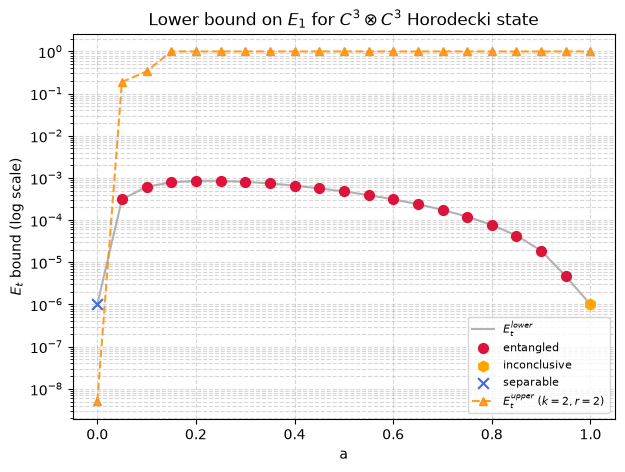

In [6]:
horodecki_res = get_SDP_bounds(
    m=3,
    generator=horodecki,
    label="C3C3_horodecki",
    param_range=(0.00, 1.0, 0.05),
)
plot_Etl_bounds(horodecki_res, "Lower bound on $E_1$ for $C^3 \\otimes C^3$ Horodecki state", xlabel="a", param_range=(0.00, 1.0, 0.05))

## CrossHatch + max mix

[get_SDP_bounds] 21/21 point(s) already in sdp_results/cross_hatch_maxmixed_m3_k2.jsonl, computing the remaining 0


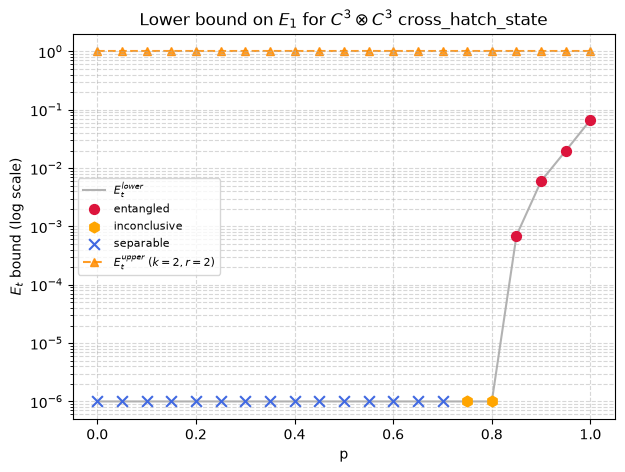

In [7]:
crosshatch_gen = convex_combination_generator(cross_hatch(), max_mixed(9))
crosshatch_res = get_SDP_bounds(
    m=3,
    generator=crosshatch_gen,
    label="cross_hatch_maxmixed",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(crosshatch_res, "Lower bound on $E_1$ for $C^3 \\otimes C^3$ cross_hatch_state", param_range=(0.0, 1.0, 0.05))

UPB

[get_SDP_bounds] 21/21 point(s) already in sdp_results/UPB_maxmixed_m3_k2.jsonl, computing the remaining 0


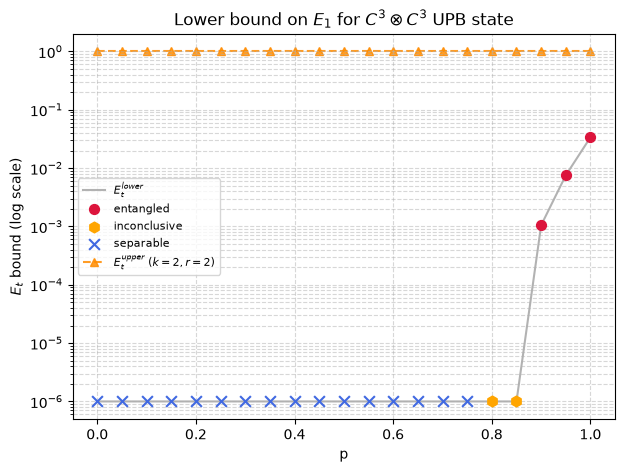

In [8]:
upb_gen = convex_combination_generator(tiles_upb(), max_mixed(9))
upb_res = get_SDP_bounds(
    m=3,
    generator=upb_gen,
    label="UPB_maxmixed",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(upb_res, "Lower bound on $E_1$ for $C^3 \\otimes C^3$ UPB state", param_range=(0.0, 1.0, 0.05))

## Pyramid UPB

[get_SDP_bounds] 21/21 point(s) already in sdp_results/pyramid_upb_maxmixed_m3_k2.jsonl, computing the remaining 0


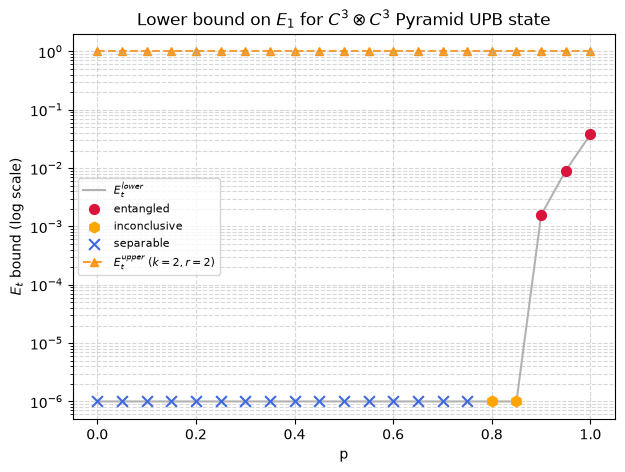

In [9]:
pyramid_gen = convex_combination_generator(pyramid_upb(), max_mixed(9))
pyramid_res = get_SDP_bounds(
    m=3,
    generator=pyramid_gen,
    label="pyramid_upb_maxmixed",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(pyramid_res, "Lower bound on $E_1$ for $C^3 \\otimes C^3$ Pyramid UPB state", param_range=(0.0, 1.0, 0.05))

## Parametrized UPB

Six-parameter family generalizing Pyramid and Tiles; using arbitrary angles away from
both special cases (`gamma`, `teta` != 0, pi/2, pi so the basis stays unextendible).

[get_SDP_bounds] 21/21 point(s) already in sdp_results/parametrized_upb_maxmixed_m3_k2.jsonl, computing the remaining 0


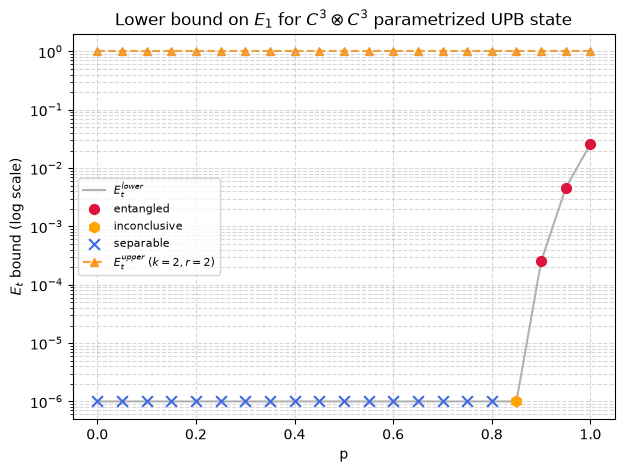

In [10]:
parametrized_state = parametrized_upb(
    gamma_a=1.0,
    teta_a=1.2,
    phi_a=0.3,
    gamma_b=0.9,
    teta_b=1.1,
    phi_b=0.5,
)
parametrized_gen = convex_combination_generator(parametrized_state, max_mixed(9))
parametrized_res = get_SDP_bounds(
    m=3,
    generator=parametrized_gen,
    label="parametrized_upb_maxmixed",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(parametrized_res, "Lower bound on $E_1$ for $C^3 \\otimes C^3$ parametrized UPB state", param_range=(0.0, 1.0, 0.05))

## Chessboard

[get_SDP_bounds] 21/21 point(s) already in sdp_results/chessboard_maxmixed_m3_k2.jsonl, computing the remaining 0


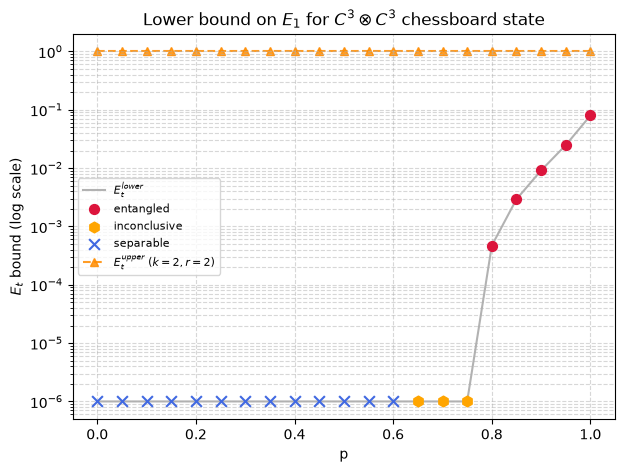

In [11]:
chessboard_gen = convex_combination_generator(chessboard_extremal_PPT(), max_mixed(9))
chessboard_res = get_SDP_bounds(
    m=3,
    generator=chessboard_gen,
    label="chessboard_maxmixed",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(chessboard_res, "Lower bound on $E_1$ for $C^3 \\otimes C^3$ chessboard state", param_range=(0.0, 1.0, 0.05))

[get_SDP_bounds] 21/21 point(s) already in sdp_results/random_PPT_m3_k2.jsonl, computing the remaining 0


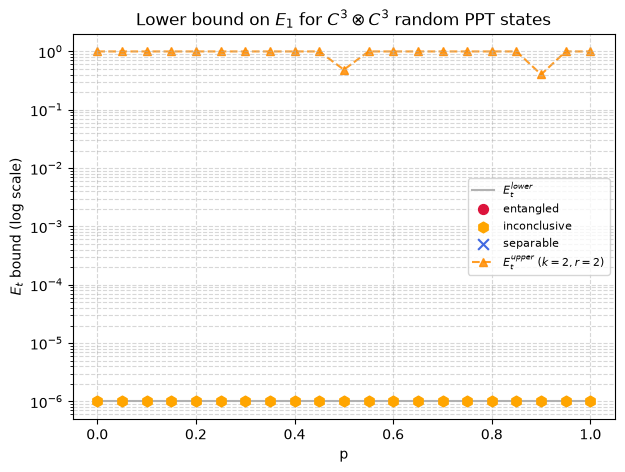

In [12]:
from CmCn_entangled.random_PPT import random_PPT_gen

random_edge_PPT_res = get_SDP_bounds(
    m=3,
    generator=random_PPT_gen(3, 3),
    label="random PPT",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(random_edge_PPT_res, "Lower bound on $E_1$ for $C^3 \\otimes C^3$ random PPT states", param_range=(0.0, 1.0, 0.05))

[get_SDP_bounds] 21/21 point(s) already in sdp_results/random_edge_PPT_m3_k2.jsonl, computing the remaining 0


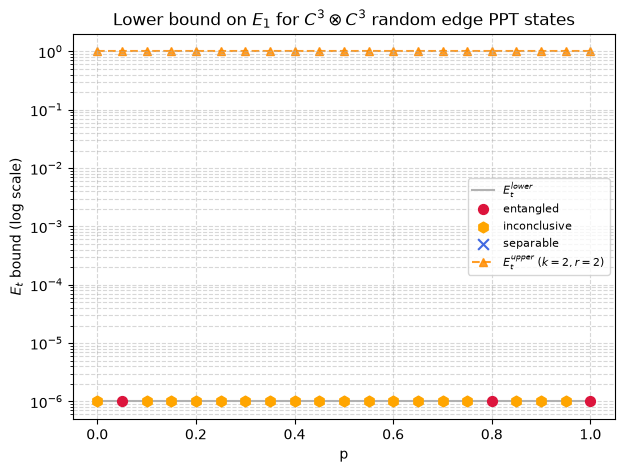

In [13]:
from CmCn_entangled.edge_PPT import random_edge_PPT_gen

random_edge_PPT_res = get_SDP_bounds(
    m=3,
    generator=random_edge_PPT_gen(3, 3, 50),
    label="random edge PPT",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(random_edge_PPT_res, "Lower bound on $E_1$ for $C^3 \\otimes C^3$ random edge PPT states", param_range=(0.0, 1.0, 0.05))

[get_SDP_bounds] 21/21 point(s) already in sdp_results/random_not_PPT_m3_k2.jsonl, computing the remaining 0


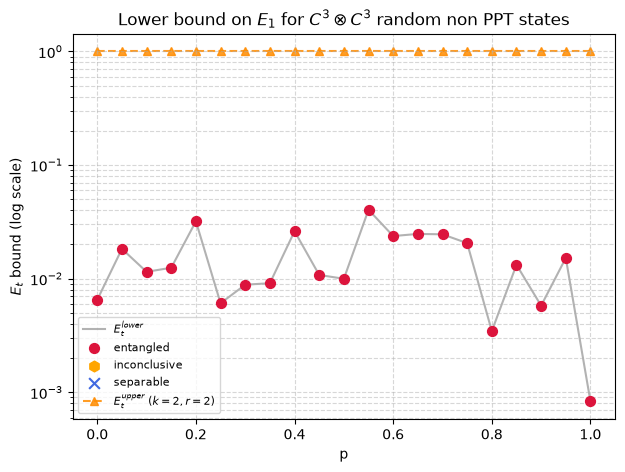

In [14]:
from CmCn_entangled.random_PPT import random_not_PPT_gen

random_not_PPT_res = get_SDP_bounds(
    m=3,
    generator=random_not_PPT_gen(3, 3),
    label="random not PPT",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(random_not_PPT_res, "Lower bound on $E_1$ for $C^3 \\otimes C^3$ random non PPT states", param_range=(0.0, 1.0, 0.05))

## Random NPT + white noise

Each of `N_STATES` random NPT (hence entangled) states in $C^3 \otimes C^3$ is mixed
with the maximally mixed state, $\rho(p) = p\,\rho_{NPT} + (1-p)\,I/9$, and the
resulting bounds are averaged over the batch.

The states are drawn from a seeded RNG, so each one is reproducible from its label
(`random_NPT_whitenoise_seed<i>`): re-running the cell reuses the cached points, and
widening or refining `npt_noise_range` later extends the *same* states instead of
silently averaging over a fresh batch.


random NPT + white noise:   0%|          | 0/10 [00:00<?, ?it/s]

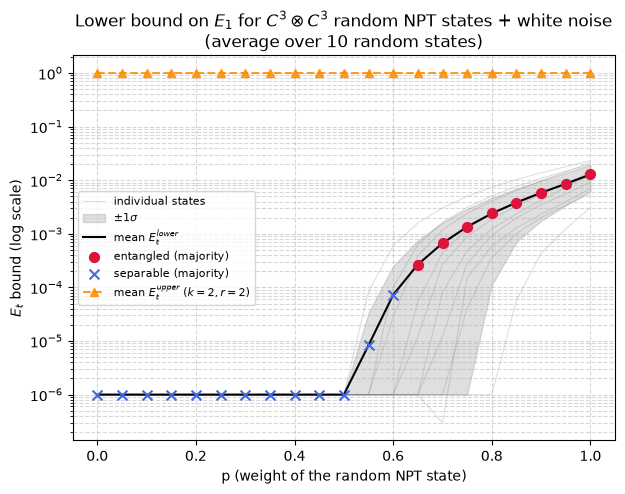

In [15]:
from toqito.states import max_mixed

N_STATES = 10  # how many random NPT states to average over
BASE_SEED = 0  # bump this to draw a different batch
npt_noise_range = (0.0, 1.0, 0.05)


def random_density_matrix_hs(d, rng):
    """Random density matrix of dimension d, Hilbert-Schmidt (Ginibre) distributed."""
    G = rng.normal(size=(d, d)) + 1j * rng.normal(size=(d, d))
    rho = G @ G.conj().T
    return rho / np.trace(rho).real


def partial_transpose_B(rho, m, n):
    """Partial transpose on the second subsystem of an (m x n) bipartite state."""
    return rho.reshape(m, n, m, n).transpose(0, 3, 2, 1).reshape(m * n, m * n)


def random_NPT_state(m, n, seed, tol=1e-9, max_tries=1000):
    """
    Draw a random density matrix on C^m x C^n whose partial transpose has a
    negative eigenvalue (NPT, hence entangled).

    Deterministic given `seed`: the same seed always gives the same state, so a
    cache file can be tied to the state that produced it and a sweep can be
    extended later without silently mixing two different random states.

    (If you would rather use the notebook's own sampler, replace the body with
    `return random_not_PPT_gen(m, n)(...)` -- but then the caching guarantee
    above no longer holds, since that draw is not reproducible from the label.)
    """
    rng = np.random.default_rng(seed)
    for _ in range(max_tries):
        rho = random_density_matrix_hs(m * n, rng)
        if np.linalg.eigvalsh(partial_transpose_B(rho, m, n)).min() < -tol:
            return rho
    raise RuntimeError(f"no NPT state found in {max_tries} draws (seed {seed})")


def average_SDP_bounds(results, label="average"):
    """
    Average several get_SDP_bounds() results sharing the same parameter grid.

    Returns the usual arrays (means over the batch) plus `Etl_std` / `Etu_std`,
    the fraction of states judged entangled / separable at each p, and
    `separable` set to the majority verdict so the result can be handed to
    plot_Etl_bounds directly.
    """
    p_vals = np.asarray(results[0]["p_vals"], dtype=float)
    for r in results:
        if len(r["p_vals"]) != len(p_vals) or not np.allclose(r["p_vals"], p_vals):
            raise ValueError("all results must share the same parameter grid")

    stack = lambda key: np.vstack([np.asarray(r[key], dtype=float) for r in results])
    Etl, Etu = stack("Etl_vals"), stack("Etu_vals")
    sep = stack("separable").astype(int)
    majority = np.array([np.bincount(col, minlength=3).argmax() for col in sep.T])

    return {
        "p_vals": p_vals,
        "obj_vals": np.nanmean(stack("obj_vals"), axis=0),
        "obj_max_vals": np.nanmean(stack("obj_max_vals"), axis=0),
        "Etl_vals": np.nanmean(Etl, axis=0),
        "Etl_std": np.nanstd(Etl, axis=0),
        "Etu_vals": np.nanmean(Etu, axis=0),
        "Etu_std": np.nanstd(Etu, axis=0),
        "separable": majority,
        "frac_entangled": (sep == 0).mean(axis=0),
        "frac_separable": (sep == 2).mean(axis=0),
        "n_states": len(results),
        "m": results[0]["m"],
        "k": results[0]["k"],
        "label": label,
        "range": results[0]["range"],
    }


def plot_Etl_bounds_avg(avg, title, trials=None, xlabel="p"):
    """
    Plot an average_SDP_bounds() result: mean lower bound with a +/- 1 sigma band,
    the individual sweeps underneath, and the mean upper bound. Markers use the
    same color code as plot_Etl_bounds, applied to the *majority* verdict.
    """
    eps = 1e-6
    p_vals = avg["p_vals"]
    mean = np.where(avg["Etl_vals"] <= 0, eps, avg["Etl_vals"])
    lo = np.clip(avg["Etl_vals"] - avg["Etl_std"], eps, None)
    hi = np.clip(avg["Etl_vals"] + avg["Etl_std"], eps, None)

    plt.figure(figsize=(7, 5))

    if trials:
        for i, r in enumerate(trials):
            vals = np.asarray(r["Etl_vals"], dtype=float)
            plt.plot(
                r["p_vals"],
                np.where(vals <= 0, eps, vals),
                color="gray",
                alpha=0.25,
                linewidth=0.8,
                zorder=0,
                label="individual states" if i == 0 else None,
            )

    plt.fill_between(p_vals, lo, hi, color="gray", alpha=0.25, zorder=1, label="$\\pm 1\\sigma$")
    plt.plot(p_vals, mean, color="black", linewidth=1.5, zorder=2, label="mean $E_t^{lower}$")

    for value, color, marker, name in ((0, "crimson", "o", "entangled"), (1, "orange", "h", "inconclusive"), (2, "royalblue", "x", "separable")):
        mask = avg["separable"] == value
        if mask.any():
            plt.scatter(p_vals[mask], mean[mask], color=color, marker=marker, s=50, zorder=3, label=f"{name} (majority)")

    Etu = np.asarray(avg["Etu_vals"], dtype=float)
    if not np.all(np.isnan(Etu)):
        valid = ~np.isnan(Etu)
        plt.plot(
            p_vals[valid],
            np.where(Etu[valid] <= 0, eps, Etu[valid]),
            color="darkorange",
            linestyle="--",
            marker="^",
            markersize=6,
            alpha=0.85,
            zorder=2,
            label="mean $E_t^{upper}$ ($k{=}2, r{=}2$)",
        )

    plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("$E_{t}$ bound (log scale)")
    plt.title(f"{title}\n(average over {avg['n_states']} random states)")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=8)
    plt.show()


# p = 1 is the pure random NPT state, p = 0 is the maximally mixed state.
npt_noise_trials = []
for i in tqdm(range(N_STATES), desc="random NPT + white noise"):
    seed = BASE_SEED + i
    rho = random_NPT_state(3, 3, seed)
    npt_noise_trials.append(
        get_SDP_bounds(
            m=3,
            generator=convex_combination_generator(rho, max_mixed(9)),
            label=f"random_NPT_whitenoise_seed{seed}",
            param_range=npt_noise_range,
            verbose=False,
        )
    )

npt_noise_avg = average_SDP_bounds(npt_noise_trials, label="random_NPT_whitenoise")
plot_Etl_bounds_avg(
    npt_noise_avg,
    "Lower bound on $E_1$ for $C^3 \\otimes C^3$ random NPT states + white noise",
    trials=npt_noise_trials,
    xlabel="p (weight of the random NPT state)",
)

## $\mathbb{C}^3 \otimes \mathbb{C}^3$ Yu-Oh states

In [16]:
from CmCn_entangled.yu_oh import yu_oh_gen

yu_oh:   0%|          | 0/121 [00:00<?, ?it/s]

[get_SDP_bounds_2d] 70 cached / 0 new point(s); sdp_results/yu_oh_m3_k2_2d.jsonl now holds 94


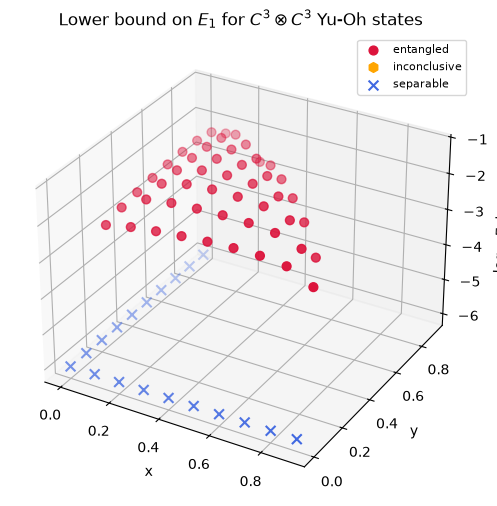

In [17]:
yu_oh_3_range = (0.0, 1.0, 0.1)
yu_oh_3_res = get_SDP_bounds_2d(
    m=3,
    generator=yu_oh_gen(3, *yu_oh_3_range),
    label="yu_oh",
    param_range=yu_oh_3_range,
)
plot_Etl_bounds_3d(
    yu_oh_3_res,
    "Lower bound on $E_1$ for $C^3 \\otimes C^3$ Yu-Oh states",
    param_range=yu_oh_3_range,
)

## Steering state

steering:   0%|          | 0/121 [00:00<?, ?it/s]

[get_SDP_bounds_2d] 51 cached / 0 new point(s); sdp_results/steering_m3_k2_2d.jsonl now holds 51


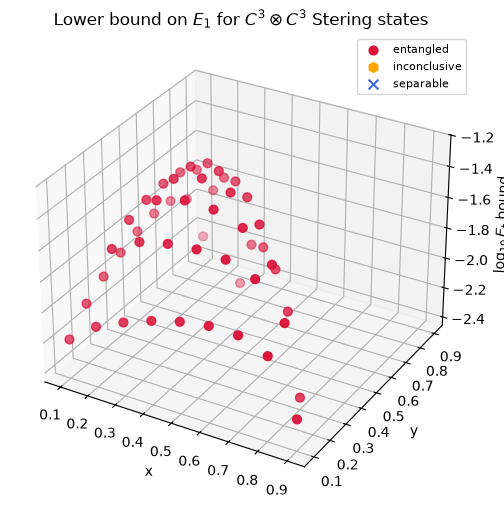

In [18]:
from C3C3_PPT_entangled.steering import steering_state_gen

steering_range = (0.0, 1.0, 0.1)
steering_res = get_SDP_bounds_2d(
    m=3,
    generator=steering_state_gen(*steering_range),
    label="steering",
    param_range=steering_range,
)
plot_Etl_bounds_3d(
    steering_res,
    "Lower bound on $E_1$ for $C^3 \\otimes C^3$ Stering states",
    param_range=steering_range,
)

# Entangled mixed state in $\mathbb{C}^4 \otimes \mathbb{C}^4$

## Pianni

[get_SDP_bounds] 11/11 point(s) already in sdp_results/pianni_maxmixed_m4_k2.jsonl, computing the remaining 0


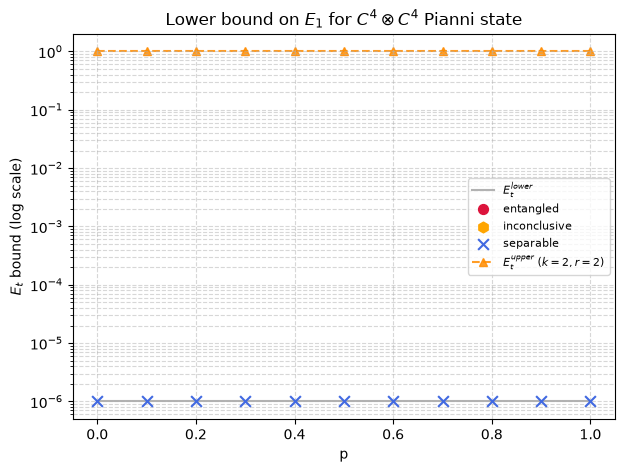

In [19]:
from bound_entangled.c4_otimes_c4 import pianni

pianni_gen = convex_combination_generator(pianni(), max_mixed(4**2))
pianni_res = get_SDP_bounds(
    m=4,
    generator=pianni_gen,
    label="pianni_maxmixed",
    param_range=(0.0, 1.0, 0.1),
)
plot_Etl_bounds(pianni_res, "Lower bound on $E_1$ for $C^4 \\otimes C^4$ Pianni state", param_range=(0.0, 1.0, 0.1))

## GenTiles1

[get_SDP_bounds] 11/11 point(s) already in sdp_results/gentiles1_d4_maxmixed_m4_k2.jsonl, computing the remaining 0


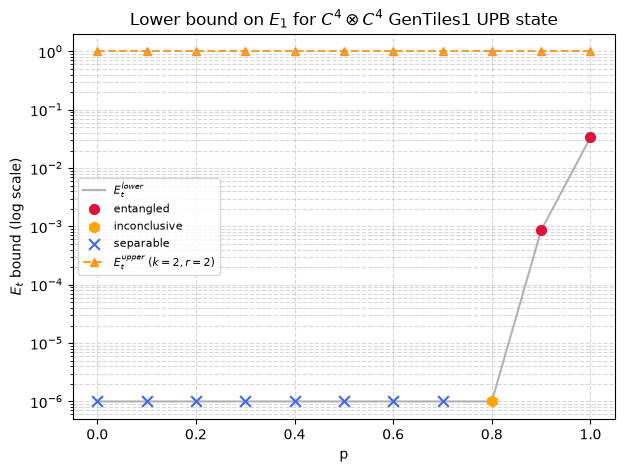

In [20]:
from bound_entangled.cd_otimes_cd import gen_tiles1

gentiles1_gen = convex_combination_generator(gen_tiles1(4), max_mixed(4**2))
gentiles1_res = get_SDP_bounds(
    m=4,
    generator=gentiles1_gen,
    label="gentiles1_d4_maxmixed",
    param_range=(0.0, 1.0, 0.1),
)
plot_Etl_bounds(gentiles1_res, "Lower bound on $E_1$ for $C^4 \\otimes C^4$ GenTiles1 UPB state", param_range=(0.0, 1.0, 0.1))

## $\mathbb{C}^4 \otimes \mathbb{C}^4$ Yu-Oh states

yu_oh:   0%|          | 0/121 [00:00<?, ?it/s]

[get_SDP_bounds_2d] 56 cached / 0 new point(s); sdp_results/yu_oh_m4_k2_2d.jsonl now holds 56


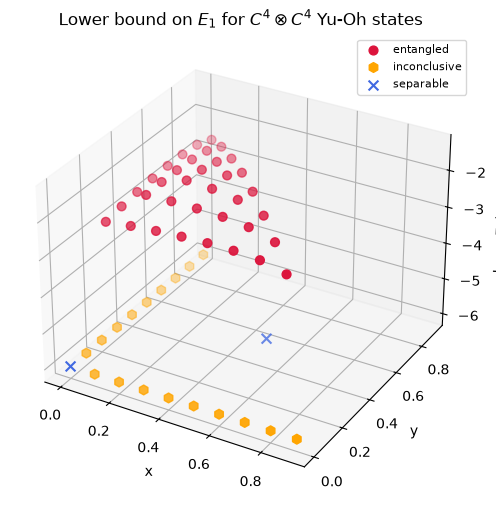

In [21]:
yu_oh_4_range = (0.0, 1.0, 0.1)
yu_oh_4_res = get_SDP_bounds_2d(
    m=4,
    generator=yu_oh_gen(4, *yu_oh_4_range),
    label="yu_oh",
    param_range=yu_oh_4_range,
)
plot_Etl_bounds_3d(
    yu_oh_4_res,
    "Lower bound on $E_1$ for $C^4 \\otimes C^4$ Yu-Oh states",
    param_range=yu_oh_4_range,
)

# Generic $\mathbb{C}^m \otimes \mathbb{C}^n$ constructions

`bound_entangled.cm_otimes_cn` also exposes the building blocks used above
(`grid_state`, `generalized_grid_state`, `gen_tiles2`) directly, parametrized
by arbitrary graphs/hyperedges/dimensions rather than the fixed examples
(`sn3_grid_state`, `gen_tiles1`) built on top of them. `get_SDP_bounds` only
supports square $m \times m$ states, so the examples below all use $m = n$.

## Grid state ($4 \times 4$)

[get_SDP_bounds] 11/11 point(s) already in sdp_results/grid_state_4x4_maxmixed_m4_k2.jsonl, computing the remaining 0


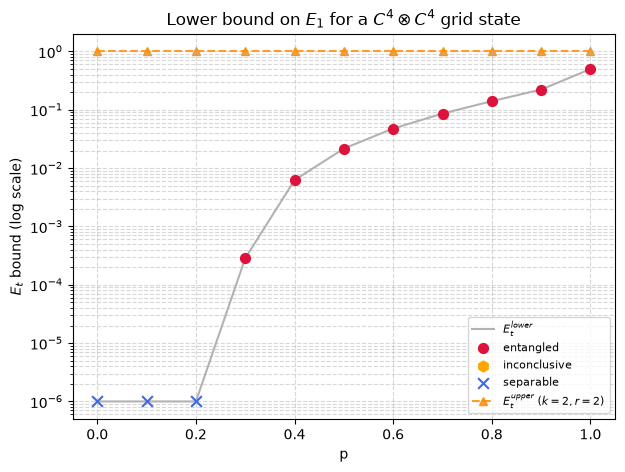

In [22]:
from bound_entangled.cm_otimes_cn import grid_state

grid_ex = grid_state(
    (4, 4),
    ((0, 0), (1, 1)),
    ((1, 2), (2, 3)),
    ((0, 3), (3, 0)),
)
grid_gen = convex_combination_generator(grid_ex, max_mixed(4**2))
grid_res = get_SDP_bounds(
    m=4,
    generator=grid_gen,
    label="grid_state_4x4_maxmixed",
    param_range=(0.0, 1.0, 0.1),
)
plot_Etl_bounds(grid_res, "Lower bound on $E_1$ for a $C^4 \\otimes C^4$ grid state", param_range=(0.0, 1.0, 0.1))

## Generalized grid state ($3 \times 3$)

Same idea as `grid_state`, but mixing over hyperedges spanning more than two
vertices instead of plain graph edges (see `sn3_grid_state`, which is built
this way at $5 \times 5$).

[get_SDP_bounds] 21/21 point(s) already in sdp_results/generalized_grid_state_3x3_maxmixed_m3_k2.jsonl, computing the remaining 0


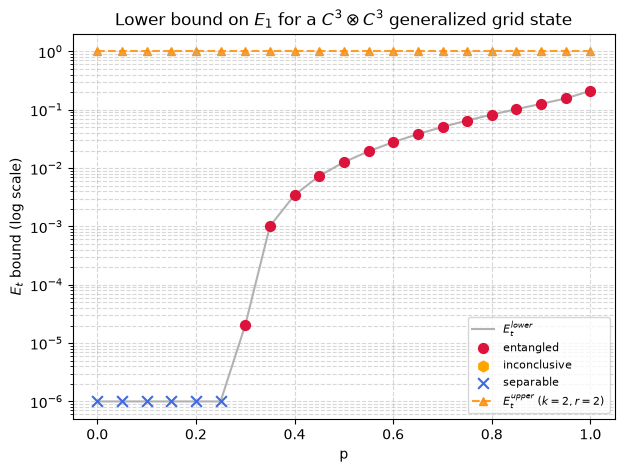

In [23]:
from bound_entangled.cm_otimes_cn import generalized_grid_state

generalized_grid_ex = generalized_grid_state(
    (3, 3),
    [(0, 0)],
    [(1, 1), (2, 2)],
    [(0, 1), (1, 0), (2, 2)],
)
generalized_grid_gen = convex_combination_generator(generalized_grid_ex, max_mixed(3**2))
generalized_grid_res = get_SDP_bounds(
    m=3,
    generator=generalized_grid_gen,
    label="generalized_grid_state_3x3_maxmixed",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(generalized_grid_res, "Lower bound on $E_1$ for a $C^3 \\otimes C^3$ generalized grid state", param_range=(0.0, 1.0, 0.05))

## GenTiles2 ($4 \times 4$)

[get_SDP_bounds] 11/11 point(s) already in sdp_results/gentiles2_4x4_maxmixed_m4_k2.jsonl, computing the remaining 0


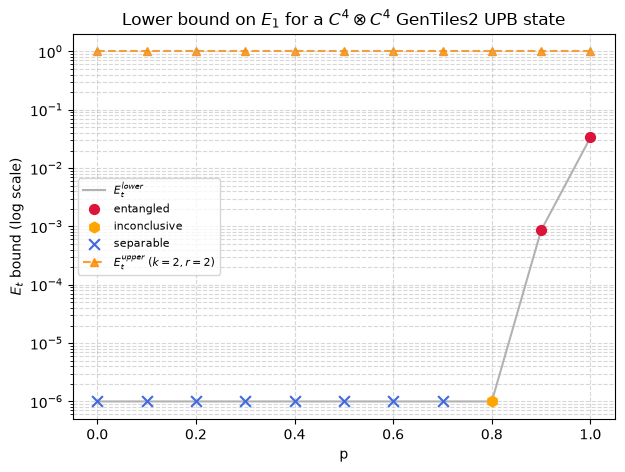

In [24]:
from bound_entangled.cm_otimes_cn import gen_tiles2

gentiles2_gen = convex_combination_generator(gen_tiles2((4, 4)), max_mixed(4**2))
gentiles2_res = get_SDP_bounds(
    m=4,
    generator=gentiles2_gen,
    label="gentiles2_4x4_maxmixed",
    param_range=(0.0, 1.0, 0.1),
)
plot_Etl_bounds(gentiles2_res, "Lower bound on $E_1$ for a $C^4 \\otimes C^4$ GenTiles2 UPB state", param_range=(0.0, 1.0, 0.1))

[overlay] 'pianni maxmixed' has no point marked entangled, skipping


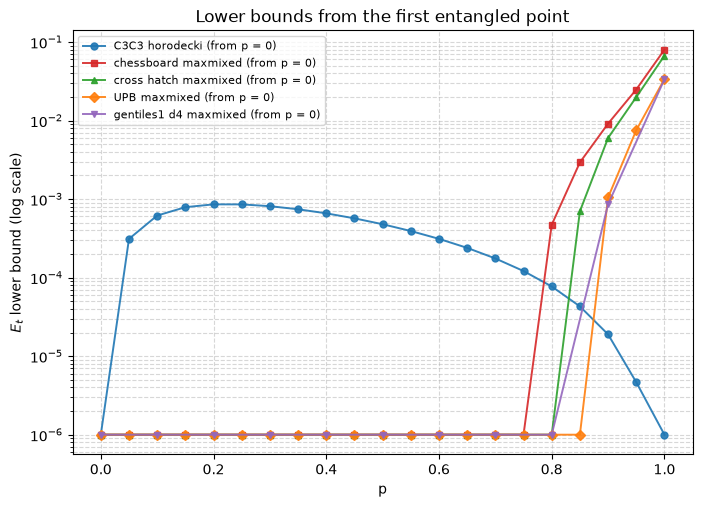

<Axes: title={'center': 'Lower bounds from the first entangled point'}, xlabel='p', ylabel='$E_{t}$ lower bound (log scale)'>

In [25]:
_OVERLAY_COLORS = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b", "#e377c2", "#17becf", "#bcbd22", "#7f7f7f"]
_OVERLAY_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]


def _pretty_label(name):
    """Turn a cache filename into something readable:
    'C3C3_horodecki_m3_k2' -> 'C3C3 horodecki (m=3)'."""
    if name.endswith(".jsonl"):
        name = name[: -len(".jsonl")]
    if name.endswith("_2d"):
        name = name[: -len("_2d")]
    suffix = ""
    parts = name.split("_")
    if len(parts) >= 3 and parts[-2][:1] == "m" and parts[-2][1:].isdigit() and parts[-1][:1] == "k" and parts[-1][1:].isdigit():
        m, k = parts[-2][1:], parts[-1][1:]
        # suffix = f" (m={m})" if k == "2" else f" (m={m}, k={k})"
        parts = parts[:-2]
    return " ".join(parts) + suffix


def plot_Etl_bounds_overlay(results, title, labels=None, param_range=None, xlabel="p", ax=None):
    """
    Overlay the E_t lower bounds of several 1-parameter sweeps on one plot, each
    curve starting at its own first entangled point. Upper bounds are ignored.

    Since every plotted point is (at or past) an entangled one, the separable /
    inconclusive color code of plot_Etl_bounds is not used: each sweep simply
    gets its own color and marker.

    Parameters
    ----------
    results : list
        Each entry is either a dict returned by get_SDP_bounds() /
        load_SDP_bounds(), or the path of a .jsonl cache file.
    title : str
        Plot title.
    labels : list of str, optional
        Legend entries. Defaults to each result's own "label" field.
    param_range : (start, end, step) or list of them, optional
        Restricts the points considered -- one range applied to every sweep, or
        one range per sweep. Note the first entangled point is searched for
        *after* this restriction.
    ax : matplotlib axes, optional
        Draw on an existing axes instead of creating a figure.

    Returns
    -------
    The axes that was drawn on, so the caller can keep tweaking it.
    """
    n = len(results)
    if labels is not None and len(labels) != n:
        raise ValueError(f"got {len(labels)} labels for {n} results")

    if param_range is None:
        ranges = [None] * n
    elif isinstance(param_range[0], (tuple, list, type(None))):
        if len(param_range) != n:
            raise ValueError(f"got {len(param_range)} ranges for {n} results")
        ranges = list(param_range)
    else:
        ranges = [param_range] * n

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5.5))

    eps = 1e-6
    n_drawn = 0

    for i, (item, rng) in enumerate(zip(results, ranges)):
        res = _as_results(item, rng)
        name = labels[i] if labels is not None else _pretty_label(res.get("label") or f"series {i}")

        p_vals = np.asarray(res["p_vals"], dtype=float)
        Etl_vals = np.asarray(res["Etl_vals"], dtype=float)
        separable = np.asarray(res["separable"], dtype=int)

        if len(p_vals) == 0:
            print(f"[overlay] '{name}' has no points in that range, skipping")
            continue

        # the sweep is not necessarily stored in ascending order
        order = np.argsort(p_vals)
        p_vals, Etl_vals, separable = p_vals[order], Etl_vals[order], separable[order]

        entangled = np.flatnonzero(separable == 0)
        if len(entangled) == 0:
            print(f"[overlay] '{name}' has no point marked entangled, skipping")
            continue

        #controls if the entangled vals are shown
        # first = entangled[0]
        # p_vals, Etl_vals = p_vals[first:], Etl_vals[first:]

        ax.plot(
            p_vals,
            np.where(Etl_vals <= 0, eps, Etl_vals),
            color=_OVERLAY_COLORS[i % len(_OVERLAY_COLORS)],
            marker=_OVERLAY_MARKERS[i % len(_OVERLAY_MARKERS)],
            markersize=5,
            linewidth=1.4,
            alpha=0.9,
            label=f"{name} (from {xlabel} = {_pkey(p_vals[0]):g})",
        )
        n_drawn += 1

    if n_drawn == 0:
        print(f"[overlay] nothing to plot for '{title}'")
        return ax

    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("$E_{t}$ lower bound (log scale)")
    ax.set_title(title)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(fontsize=8)
    plt.show()
    return ax


plot_Etl_bounds_overlay(
    [
        "sdp_results/C3C3_horodecki_m3_k2.jsonl",
          "sdp_results/chessboard_maxmixed_m3_k2.jsonl",
        "./sdp_results/cross_hatch_maxmixed_m3_k2.jsonl",
        "sdp_results/UPB_maxmixed_m3_k2.jsonl",
        "sdp_results/gentiles1_d4_maxmixed_m4_k2.jsonl",
        "sdp_results/pianni_maxmixed_m4_k2.jsonl",
    ],
    "Lower bounds from the first entangled point",
    param_range=(0.0, 1.0, 0.05),
)

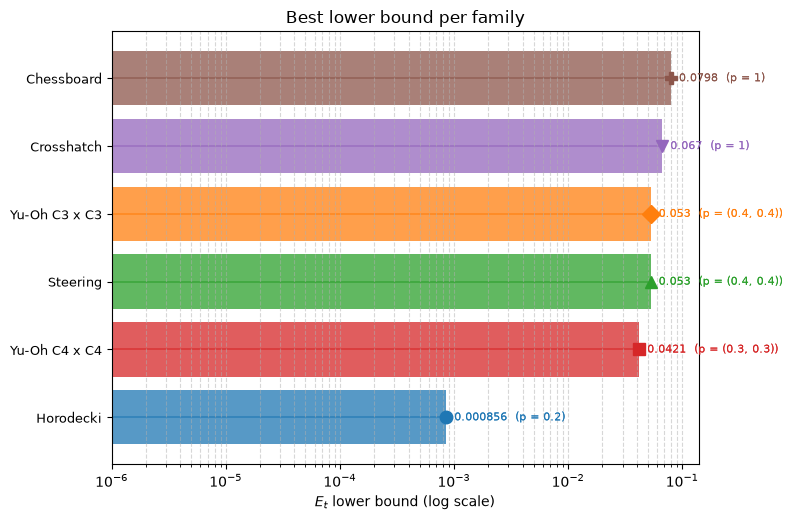

(<Axes: title={'center': 'Best lower bound per family'}, xlabel='$E_{t}$ lower bound (log scale)'>,
 [{'label': 'Horodecki',
   'p': 0.2,
   'Etl': 0.0008564024979249574,
   'Etu': 1.0,
   'obj': 0.0008556690726865875,
   'separable': 0,
   'is_2d': False},
  {'label': 'Yu-Oh C4 x C4',
   'p': (0.3, 0.3),
   'Etl': 0.04205049061198518,
   'Etu': nan,
   'obj': 0.0402822468512765,
   'separable': 0,
   'is_2d': True},
  {'label': 'Steering',
   'p': (0.4, 0.4),
   'Etl': 0.052972841182957975,
   'Etu': nan,
   'obj': 0.05016671927996309,
   'separable': 0,
   'is_2d': True},
  {'label': 'Yu-Oh C3 x C3',
   'p': (0.4, 0.4),
   'Etl': 0.052972841368264634,
   'Etu': nan,
   'obj': 0.05016671944563727,
   'separable': 0,
   'is_2d': True},
  {'label': 'Crosshatch',
   'p': 1.0,
   'Etl': 0.06698448435072346,
   'Etu': 1.0,
   'obj': 0.06249756320699119,
   'separable': 0,
   'is_2d': False},
  {'label': 'Chessboard',
   'p': 1.0,
   'Etl': 0.07979131299349418,
   'Etu': 1.0,
   'obj': 0.07

In [29]:
def _records_from(source):
    """(records dict, is_2d, default label) from a .jsonl path or a result dict."""
    if isinstance(source, str):
        keyfunc = lambda rec: _xykey_of(rec) if "x" in rec else _pkey(rec["p"])
        records = _load_records(source, keyfunc)
        name = os.path.basename(source)
        if name.endswith(".jsonl"):
            name = name[: -len(".jsonl")]
        is_2d = any("x" in rec for rec in records.values())
        return records, is_2d, name

    # a dict returned by get_SDP_bounds / get_SDP_bounds_2d
    is_2d = "x_vals" in source
    n = len(source["x_vals"] if is_2d else source["p_vals"])
    Etu_vals = source.get("Etu_vals")
    records = {}
    for i in range(n):
        if is_2d:
            key = _xykey(source["x_vals"][i], source["y_vals"][i])
            rec = {"x": key[0], "y": key[1]}
        else:
            key = _pkey(source["p_vals"][i])
            rec = {"p": key}
        rec["obj"] = float(source["obj_vals"][i])
        rec["separable"] = int(source["separable"][i])
        rec["Etl"] = float(source["Etl_vals"][i])
        rec["Etu"] = float(Etu_vals[i]) if Etu_vals is not None else float("nan")
        records[key] = rec
    return records, is_2d, source.get("label", "result")


def Etl_at(source, p=1.0, label=None):
    """
    Pull a single point out of a sweep -- the whole family reduced to one number.

    Parameters
    ----------
    source : str or dict
        Path of a .jsonl cache file (1-parameter or 2-parameter), or a dict
        returned by get_SDP_bounds() / get_SDP_bounds_2d().
    p : float, (x, y) or "max", default 1.0
        Which point to read.
          * a number for a 1-parameter sweep. p = 1 is the end of a convex
            combination with the maximally mixed state, i.e. the state itself
            with no white noise added.
          * an (x, y) pair for a 2-parameter sweep.
          * "max" to take whichever point has the largest lower bound, for the
            parametric families where the interesting member is not p = 1.
    label : str, optional
        Name to carry into the plot legend. Defaults to the file/result label.

    Returns
    -------
    dict with keys label, p, Etl, Etu, obj, separable, is_2d -- where "p" is the
    parameter value actually used (useful when p="max" picked it).
    """
    records, is_2d, default_label = _records_from(source)
    if not records:
        raise ValueError(f"{source}: no points")

    if isinstance(p, str):
        if p != "max":
            raise ValueError(f"p must be a number, an (x, y) pair or 'max', got {p!r}")

        def _bound(key):
            value = records[key].get("Etl")
            value = float("-inf") if value is None else float(value)
            return float("-inf") if np.isnan(value) else value

        key = max(records, key=_bound)
    elif is_2d:
        try:
            x, y = p
        except (TypeError, ValueError):
            raise ValueError(f"{source} is a 2-parameter sweep, p must be an (x, y) pair")
        key = _xykey(x, y)
    else:
        key = _pkey(p)

    if key not in records:
        available = sorted(records)
        if not is_2d:
            nearest = min(available, key=lambda value: abs(value - key))
            hint = f" nearest available is {nearest:g}"
        else:
            hint = f" ({len(available)} points available)"
        raise KeyError(f"{default_label}: no point at {key};{hint}")

    rec = records[key]
    return {
        "label": label or _pretty_label(default_label),
        "p": (rec["x"], rec["y"]) if is_2d else rec["p"],
        "Etl": _load_num(rec.get("Etl")),
        "Etu": _load_num(rec.get("Etu")),
        "obj": _load_num(rec.get("obj")),
        "separable": int(rec["separable"]),
        "is_2d": is_2d,
    }


def plot_Etl_points(entries, title, labels=None, sort=True, annotate=True, ax=None):
    """
    Compare families by a single point each: one lollipop per entry, log scale.
    Only the lower bound is shown.

    Parameters
    ----------
    entries : list
        Each entry is `(source, p)`, or a bare `source` meaning p = 1.0.
        `source` is a .jsonl path or a result dict (see Etl_at), and `p` is a
        number, an (x, y) pair, or "max".
    labels : list of str, optional
        Legend/axis names, one per entry. Defaults to each source's own label.
    sort : bool, default True
        Order the rows by lower bound (largest at the top) instead of by input
        order.
    annotate : bool, default True
        Write the value and the parameter used next to each marker.

    Returns
    -------
    (axes, points) -- `points` is the list of Etl_at() dicts actually plotted,
    in the order drawn, so the numbers can be reused elsewhere.
    """
    points = []
    for i, entry in enumerate(entries):
        name = None
        if isinstance(entry, (tuple, list)):
            if len(entry) == 3:
                source, p, name = entry
            elif len(entry) == 2:
                source, p = entry
            elif len(entry) == 1:
                source, p = entry[0], 1.0
            else:
                raise ValueError(f"entry {i} should be source, (source, p) or " f"(source, p, name), got {len(entry)} items")
        else:
            source, p = entry, 1.0
        if name is None and labels is not None:
            name = labels[i]
        points.append(Etl_at(source, p, label=name))

    if sort:
        # ascending, so the largest bound ends up at the top of the plot;
        # points without a bound sit at the bottom
        points.sort(key=lambda point: (0 if np.isnan(point["Etl"]) else 1, point["Etl"]))

    for point in points:
        if point["separable"] != 0:
            verdict = {1: "inconclusive", 2: "separable"}[point["separable"]]
            print(f"[points] '{point['label']}' at p = {point['p']} is marked " f"{verdict}, not entangled")

    eps = 1e-6
    values = np.array([point["Etl"] for point in points], dtype=float)
    plotted = np.where(np.isnan(values) | (values <= 0), eps, values)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 0.55 * len(points) + 2))

    y_pos = np.arange(len(points))
    for i, (point, value) in enumerate(zip(points, plotted)):
        color = _OVERLAY_COLORS[i % len(_OVERLAY_COLORS)]
        marker = _OVERLAY_MARKERS[i % len(_OVERLAY_MARKERS)]
        ax.plot([eps, value], [i, i], color=color, linewidth=1.4, alpha=0.6, zorder=1)
        ax.plot(value, i, color=color, marker=marker, markersize=9, zorder=2)
        if annotate:
            p_text = f"({point['p'][0]:g}, {point['p'][1]:g})" if point["is_2d"] else f"{point['p']:g}"
            if np.isnan(point["Etl"]):
                shown = "n/a"
            elif point["Etl"] <= 0:
                shown = "0"
            else:
                shown = f"{point['Etl']:.3g}"
            ax.annotate(f"  {shown}  (p = {p_text})", (value, i), va="center", fontsize=8, color=color)

    # ax.set_yticks(y_pos)
    # ax.set_yticklabels([point["label"] for point in points], fontsize=9)
    # ax.set_xscale("log")
    # ax.set_xlim(left=eps)
    # ax.set_xlabel("$E_{t}$ lower bound (log scale)")
    # ax.set_title(title)
    # ax.grid(True, axis="x", which="both", ls="--", alpha=0.5)
    # plt.tight_layout()
    # plt.show()
    # return ax, points

    #as histogram instead
    y_pos = np.arange(len(points))
    for i, (point, value) in enumerate(zip(points, plotted)):
        color = _OVERLAY_COLORS[i % len(_OVERLAY_COLORS)]
        ax.barh(i, value - eps, left=eps, color=color, alpha=0.75, zorder=1)
        if annotate:
            p_text = f"({point['p'][0]:g}, {point['p'][1]:g})" if point["is_2d"] else f"{point['p']:g}"
            if np.isnan(point["Etl"]):
                shown = "n/a"
            elif point["Etl"] <= 0:
                shown = "0"
            else:
                shown = f"{point['Etl']:.3g}"
            ax.annotate(f"  {shown}  (p = {p_text})", (value, i), va="center", fontsize=8, color=color)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([point["label"] for point in points], fontsize=9)
    ax.set_xscale("log")
    ax.set_xlim(left=eps)
    ax.set_xlabel("$E_{t}$ lower bound (log scale)")
    ax.set_title(title)
    ax.grid(True, axis="x", which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
    return ax, points


plot_Etl_points(
    [
        ("sdp_results/cross_hatch_maxmixed_m3_k2.jsonl", 1.0, "Crosshatch"),  # p = 1
        ("sdp_results/chessboard_maxmixed_m3_k2.jsonl", 1.0, "Chessboard"),  # p = 1
        ("sdp_results/C3C3_horodecki_m3_k2.jsonl", "max", "Horodecki"),  # you pick
        ("sdp_results/yu_oh_m3_k2_2d.jsonl", "max", "Yu-Oh C3 x C3"),  # 2d: an (x, y) pair
        ("sdp_results/yu_oh_m4_k2_2d.jsonl", "max", "Yu-Oh C4 x C4"),
        # ("sdp_results/pianni_maxmixed_m4_k2.jsonl", 1.0, "Pianni"),
        ("sdp_results/steering_m3_k2_2d.jsonl", "max", "Steering"),
    ],
    "Best lower bound per family",
)